# ***HR Analytics using Logistic Regression***

## Please follow the step-by-step instructions to:  
1. **Develop the Code** – Write the necessary code to generate the desired outputs*.  
2. **Annotate/Explain Steps** – Provide annotations or explanations of your coding steps where appropriate.   
3. **Answer Analysis Questions** – Complete the analysis questions posted on *Canvas*, using insights from your notebook outputs.  

**Note:*
- Unless otherwise specified, minor variations in formatting (e.g., labels, colors, titles) are acceptable.
- Run all cells in order, even those where you don't enter information or code.

**Disclose GenAI Usage** – If Generative AI was used, include the prompts and explain how it assisted in producing code and/or annotations using the template below.

********************************************************************************

# Section 1: Business problem description

***In this project, you have been approached by the Sophia, the HR Director of the a large manufacturing company, Beta Group. Beta Group is a large multinational company with more than 100,000 employees.***

Sophia has past performance data on around 54,000 employees. She needs help in solving two problems for her business.

1. The company is the industry leader is championing fairness in employee hiring and promotion policies, and thus Sophia wants to showcase the company's track record of fairness in promotion policies in the HR conclave scheduled to take place next month.<br> <br>She wants to develop a model to demonstrate whether age and gender have any impact on promotion for employees with similar experiences and skill sets. <br> <br> For this problem, your task is to fit an  model to identify whether employees have different chances of getting promoted based on ***gender*** and ***age***.
<br>
<br>
2. The current promotion practice for the company consists of an employee's profile analysis conducted by the HR department. Each employee profile analysis costs approximately ***200*** ***USD*** for each profile analyzed.<br><br> Sophia wants to save the cost by automating this process using a predictive model.<br>
<br>
She is aware that an automated model may make some mistakes (wrong predictions).For example, the model may recommend an employee for promotion and it turns out to be a wrong decision. This will affect the productivity of the firm. On the other hand, an employee who deserved promotion but wrongly predicted unfit for the promotion will result in lower employee satisfaction. <br>
<br>
Sophia has calculated these costs in financial terms: the decision to  wrongly promote an employee costs 600 USD to the company in terms of lost productivity, and the decision to wrongly deny a promotion costs 3,000 USD which includes employees dissatisfaction and reputational loss.
<br>

<br>Sophia wants you to develop a model that can be used for promotion decision and is willing to pay you 10% of the value that the model generates for the company.

The value generated by the model can be assessed in the following terms:

* Each prediction made by the model saves 200 USD <br>

* Each wrong promotion predicted by the model costs company 600 USD<br>

* Each wrong denial of promotion by the model costs company 3000 USD<br>
<br>

For example, in a test dataset of 1000 employees, we will make 1000 predictions. Of those, 20 will be false promotion predications and 30 will be false denial predictions.

<br>
value_generated = 1000 * 200 + (-600) * 20 + (-3000) * 30



<br>

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------

**Run all cells in order, even those where you don't enter information or code.**

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------

## **Q1-Q5 are from section 1**


### Q1 - Which of the following correctly describe the business problem?


1.   Task 1 involves fitting an explanatory model, while task 2 involves fitting a predictive model
2.   Task 1 involves fitting a predictive model, while task 2 involves fitting an explanatory model
3.   Both tasks involve fitting explanatory models
4.   Both tasks involve fitting predictive models



### Q2 Which model(s) are suitable for the two tasks?


1. Task 1 involves fitting a linear regression model, while task 2 involves fitting a logistic regression model
2. Task 1 involves fitting a logistic regression model, while task 2 involves fitting a linear regression model
3. Both tasks involve fitting linear regression models
4. Both tasks involve fitting logistic regression models


### Q3 Given the description of the company and its commitment to fairness in employee promotions, which of the following would Sophia like to see in the model output?


1.   A negative coefficient for age and a positive coefficient for gender
2.   A positive coefficient for age and a negative coefficient for gender
3.   Negative coefficients for both age and gender
4.   Positive coefficients for both age and gender
5.   Can't be determined unless we know how gender is coded; whether male or female is coded as 1
6.   None of these



### Q4 Which of the following is correct based on the information given in the business description section? (Note: The positive class is assumed to be "promoted" and "denied" is assumed as negative class).



1.   The cost of each false positive is 200
2.   The cost of each false positive is 600
3.   The cost of each false positive is 3000
4.   Can't be determined based on the information provided


### Q5 Calculate the average value (per employee in the dataset) generated by the model for a test dataset of 500 employees, out of which false positives are 15 and false negatives are 12. (Note: The positive class is assumed to be "promoted" and "denied" is assumed as negative class).

1. 55000
2. 47800
3. 110
4. 95.6



# Section 2: Importing required modules and setting options

## Import required packages

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

import matplotlib.pylab as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


In [ ]:
%matplotlib inline

# Section 3: Data Understanding
<br>

## Load the data and perform initial inspection

In [ ]:
data_df = pd.read_csv('https://raw.githubusercontent.com/rul110/datasets/refs/heads/main/HR_Promote.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Show the first 5 rows of the dataset

**Your output should look like this:**

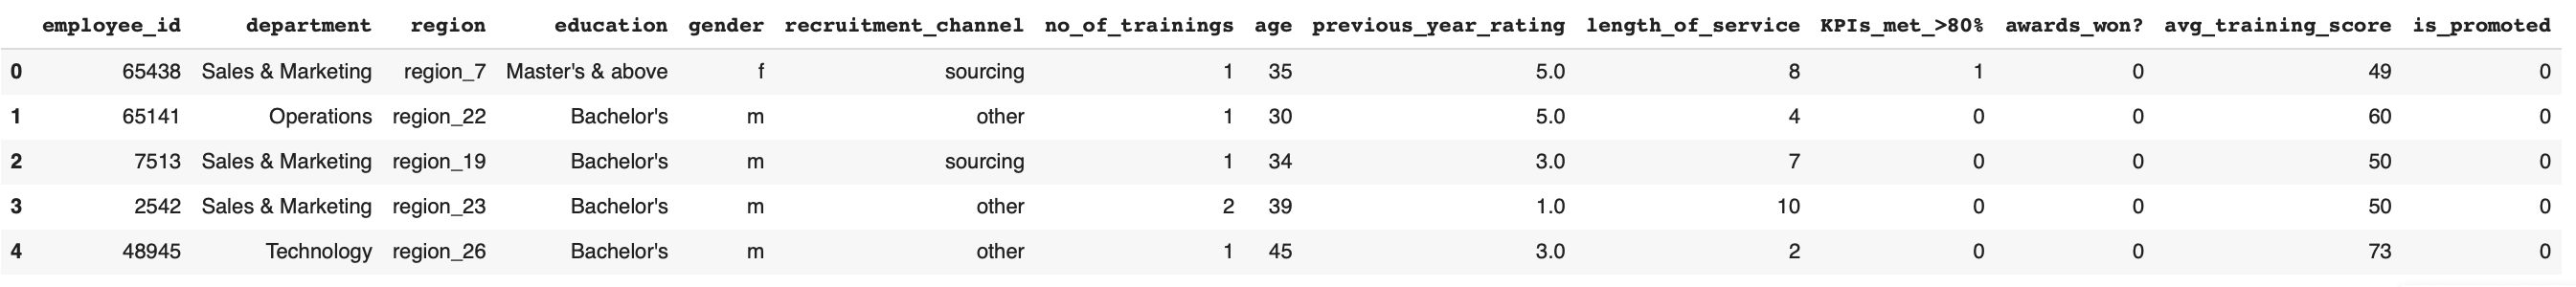

In [ ]:
# Use the head method to show the first 5 rows.
data_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


## Display the number of samples and variables

**Your output should look like this:**

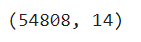

In [ ]:
# Display samples and variables using the shape attribute.
data_size = data_df.shape
print(data_size)

(54808, 14)


### Q6 Which of the following is NOT correct with respect to the number of variables in the dataset



1.   There are 12 valid predictors and 1 target variable in the given dataset
2.   There are 13 valid predictors and 1 target variable in the given dataset
3.   There is one ID variable in the given dataset
4.   The actual number of predictors used in the model can't be determined w/o running further steps



## Display the variable names,  count of non-null values, and datatypes

**Your output should look like this:**

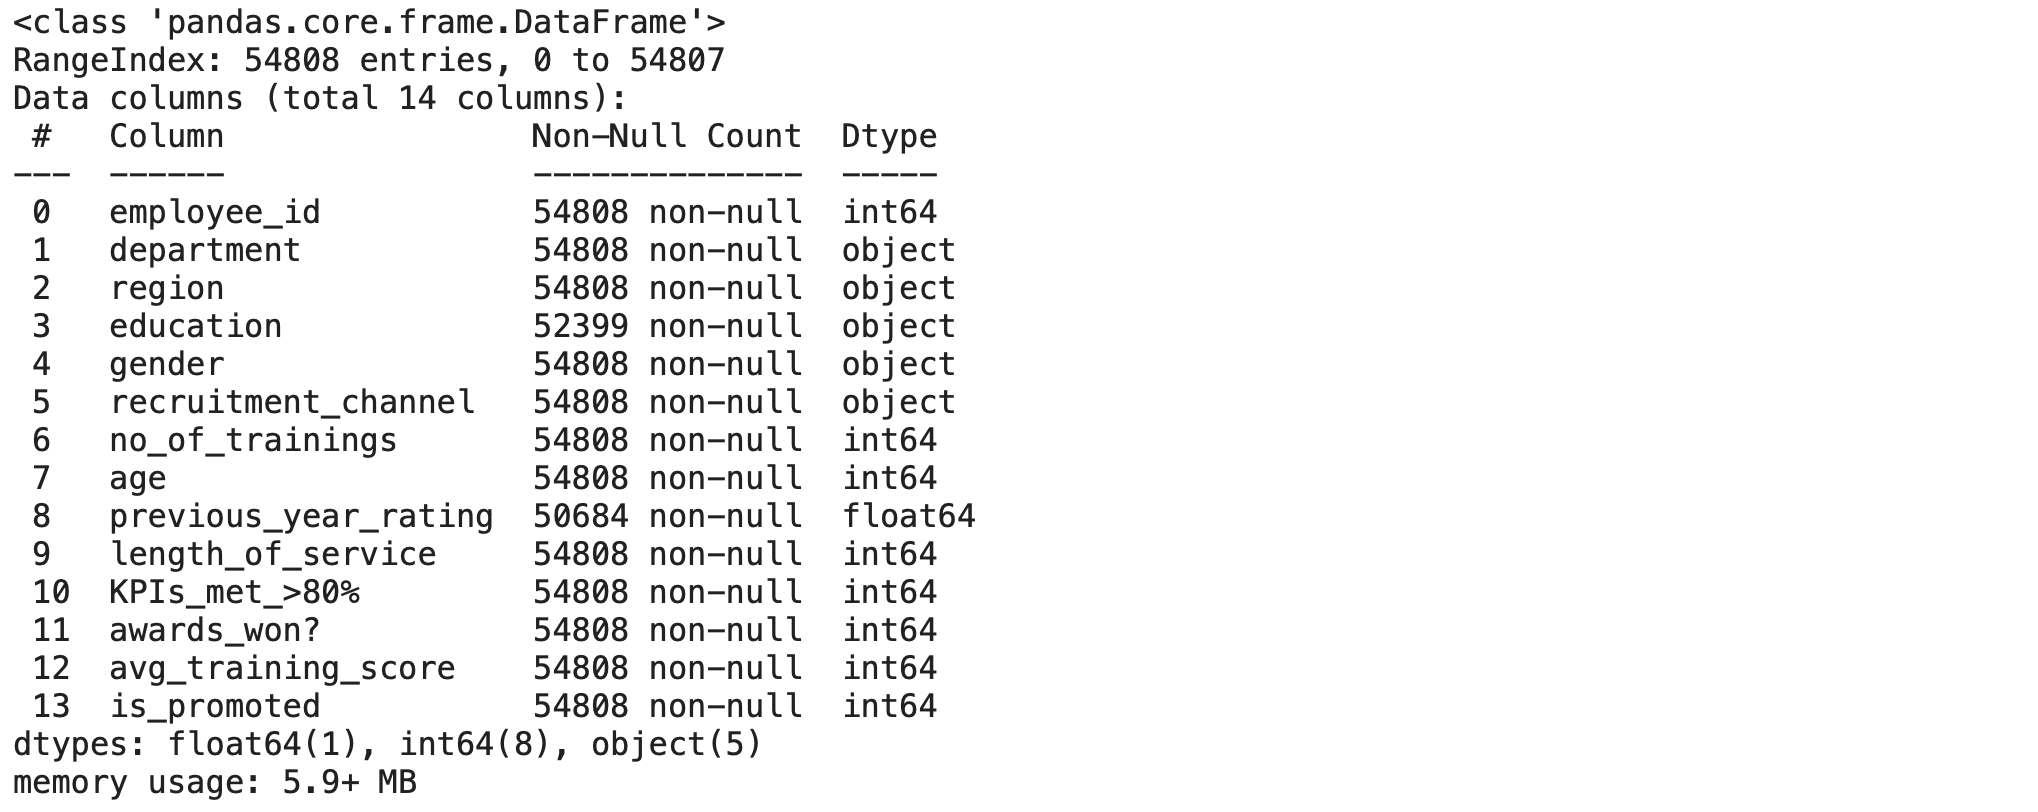

In [ ]:
# Info method displays variable names, null value count, and datatypes
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


# Section 4: Data Preprocessing

## Check for variables with missing values and calculate the percentage of missing values in each variable

**Your output should look like this:**

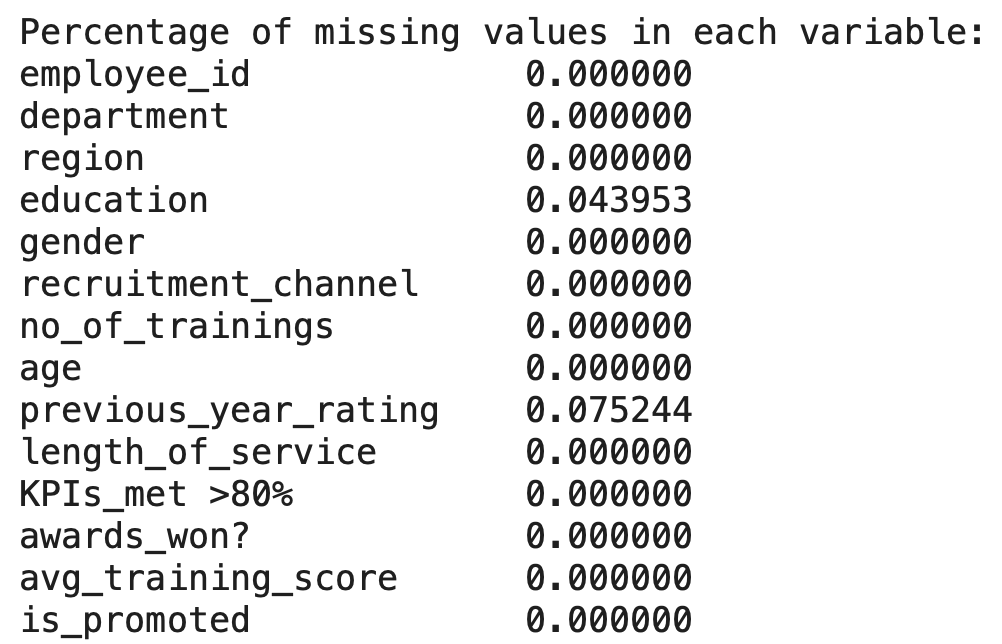

In [ ]:
# Use isnull and mean methods to calculate the percentage of missing values in each variable.
null_values= data_df.isnull().mean()
# Print results
print("Percentage of missing values in each variable:")
print(null_values)



Percentage of missing values in each variable:
employee_id             0.000000
department              0.000000
region                  0.000000
education               0.043953
gender                  0.000000
recruitment_channel     0.000000
no_of_trainings         0.000000
age                     0.000000
previous_year_rating    0.075244
length_of_service       0.000000
KPIs_met >80%           0.000000
awards_won?             0.000000
avg_training_score      0.000000
is_promoted             0.000000
dtype: float64


## Drop observations with missing values

Since there are small percentages of missing values, let's drop the observations with missing values.

In [ ]:
# Use dropna method to drop all observations with missing values
data_df = data_df.dropna(axis = 0)

## Create a y response variable and an X collection of predictors

**Hint: Are you including ideantifer variables?**

In [ ]:
# Create predictor and outcome variables that correlate to X and y
predictors = ['department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'KPIs_met >80%', 'awards_won?', 'avg_training_score']
outcome = ['is_promoted']

## Process dummy encoding first and check the size of predictors after encoding

**Your output should look like this:**

(48660, 53)

In [ ]:
# Set predictors and outcome to the variables of X and y
X = data_df[predictors]
y = data_df[outcome]

# Process dummy encoding
X = pd.get_dummies(
    X,
    dtype=int,
    drop_first=True
)

# Print size of predictors after encoding
print(X.shape)


(48660, 53)


### Q7 - Do we need to encode the target variable to categories (0/1) as we did in the Lab 5?

1.   Yes, because this is to be done every time, we run logistic regression
2.   Yes, because the probability of being promoted is a continuous variable
3.   No, because the outcome variable is already coded as "0" and "1"
4.   None of these

## If you answer to the question above is yes, perform that step in the cell below or skip to the next one.

## Check the value counts of the two classes in the outcome variable

**Your output should look like this:**

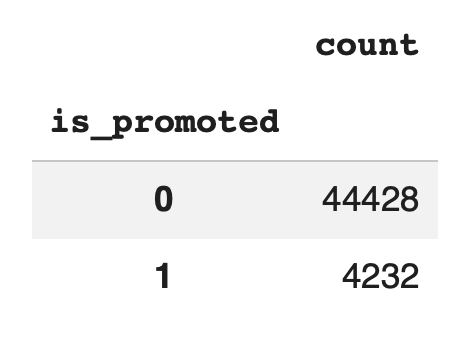

In [ ]:
# Set variable y
y = data_df['is_promoted']
# Set criteria for whether outcome variable is promoted or not_promoted
promoted = (data_df['is_promoted']== 1).sum()
not_promoted = (data_df['is_promoted']== 0).sum()
# Create table to display results
promoted_table = pd.DataFrame({'is_promoted':[0,1],
                               'count': [not_promoted, promoted]})
print(promoted_table)



   is_promoted  count
0            0  44428
1            1   4232


# Section 5: Model Development
********************************************************************
***Note: In the target variable, y, 1 is coded for "promotion", thus, "promotion" is the positive class.***
********************************************************************

## Model for Task 1

### Perform **logistic regression** with argments `LogisticRegression(max_iter=5000, random_state = 1)` on the entire dataset (X,y); output the intercept and coefficients of the model.

**Your output should look like this:**

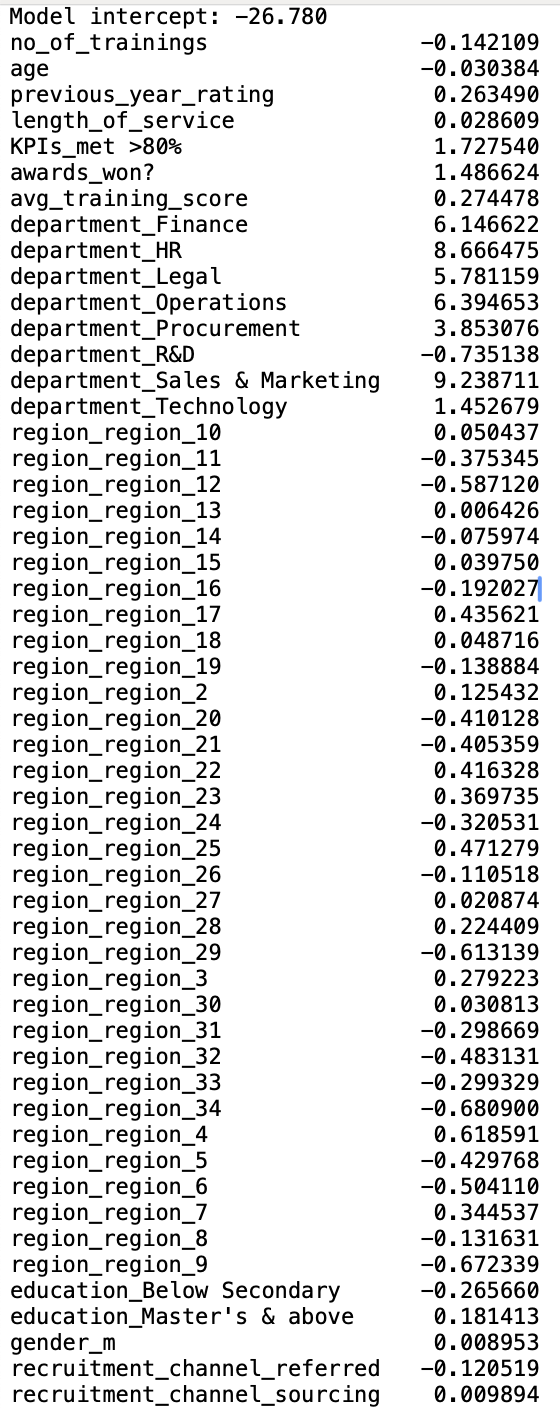

In [ ]:
# Convert categorical variable into numeric
data_df['gender_m'] = (data_df['gender'] == 'm').astype(int)
data_df = data_df.drop(columns=['gender'])

In [ ]:
# Dummy encode categorical variables
data_df = pd.get_dummies(
    data_df,
    columns=['department','region','education','recruitment_channel'],
    drop_first=True
)

In [ ]:
# Split dataset into predictors and target variable
X = data_df.drop(columns=['employee_id','is_promoted'])
y = data_df['is_promoted']

# Initialize logistic regression model, set random seed
logit_model = LogisticRegression(max_iter=5000, solver="liblinear", random_state=1)
logit_model.fit(X, y)

# Retrieve model intercept and coefficients
print(f"Model intercept: {logit_model.intercept_[0]:.3f}")

# Use for loop to print results
for name, coef in zip(X.columns, logit_model.coef_[0]):
    print(f"{name:<30}{coef:>12.6f}")

Model intercept: -22.254
no_of_trainings                  -0.188187
age                              -0.037760
previous_year_rating              0.249068
length_of_service                 0.031743
KPIs_met >80%                     1.598258
awards_won?                       1.506310
avg_training_score                0.231695
gender_m                         -0.014065
department_Finance                5.070564
department_HR                     7.131147
department_Legal                  4.683625
department_Operations             5.328873
department_Procurement            3.191903
department_R&D                   -0.749368
department_Sales & Marketing      7.716734
department_Technology             1.197552
region_region_10                 -0.323534
region_region_11                 -0.733620
region_region_12                 -0.916233
region_region_13                 -0.334333
region_region_14                 -0.421578
region_region_15                 -0.302422
region_region_16             

### Q8 Do you think the model coefficient of **gender_m** will please Sophia? (Note: in **gender_m**, 1 means male 0 means female, and in **is_promoted**, 1 means promotion)

1. No, because this shows that the probability of males being promoted is less than 0.01, very close to zero.
2. No, because it shows that males have only slightly higher odds of being promoted than females do.
3. Yes, because it shows that females have higher odds of being promoted than males.
4. Yes, because it shows that males have only slightly higher odds of being promoted than females do.



### Q9 What is the interpretation of the coefficient of **age**? (Note: **is_promoted** = 1 means promotion)
1. The probability of promotion decreases with age
2. The probability of promotion increases with age
3. The probability of promotion remains constant with age
4. There is not enough information to answer this

# Model for Task 2


### Split the data into training and test sets, setting `test_size=0.2`, `random_state=1`, and stratifying on y;

Print out the class membership of the outcome variable for both training and test sets

Display the number of obervations and the count of predictors and in the training set.

**Your output should look like this:**

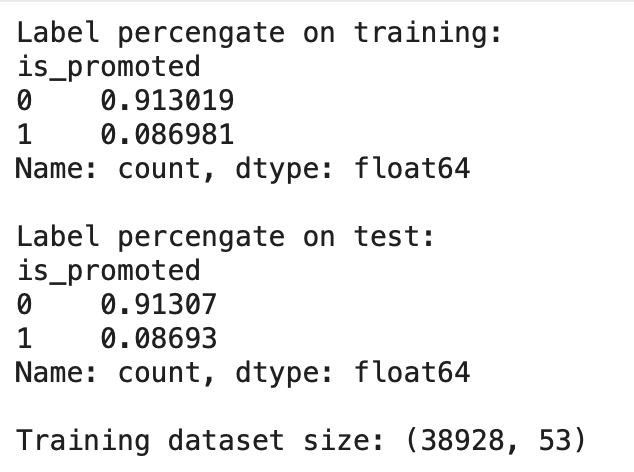

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# Check label proportions
print("Label percentage on training:")
print(y_train.value_counts(normalize=True))

print("\nLabel percentage on test:")
print(y_test.value_counts(normalize=True))

# Print dataset shape
print("\nTraining dataset size:", X_train.shape)

Label percentage on training:
is_promoted
0    0.913019
1    0.086981
Name: proportion, dtype: float64

Label percentage on test:
is_promoted
0    0.91307
1    0.08693
Name: proportion, dtype: float64

Training dataset size: (38928, 53)


### Q10 What did we achieve by using the extra argument "stratify = y" in train_test_split *function*?


1. That ensured equal proportion of promotions and non-promotions in the training data
2. That ensured equal proportion of promotions and non-promotions in the testing data

3. That ensured that the proportion of promotions and non-promotions in the training data is similar to that in testing data
4. That ensured that same number of observations were placed in the training and testing data

### Develop a logistic regression models as follows:
- Create a pipeline integrating **StandardScaler** and **LogisticRegressionCV**
- Configure **LogisticRegressionCV** with the following arguments: **LogisticRegressionCV(penalty= "l2", Cs=50, cv=5, max_iter=1000,  random_state=1)**
- Fit the pipeline on training data and save it to an object named `logit_cv`
- Print out the final **C** chosen, the model intercept and coefficients.

**Your output should look like this:**

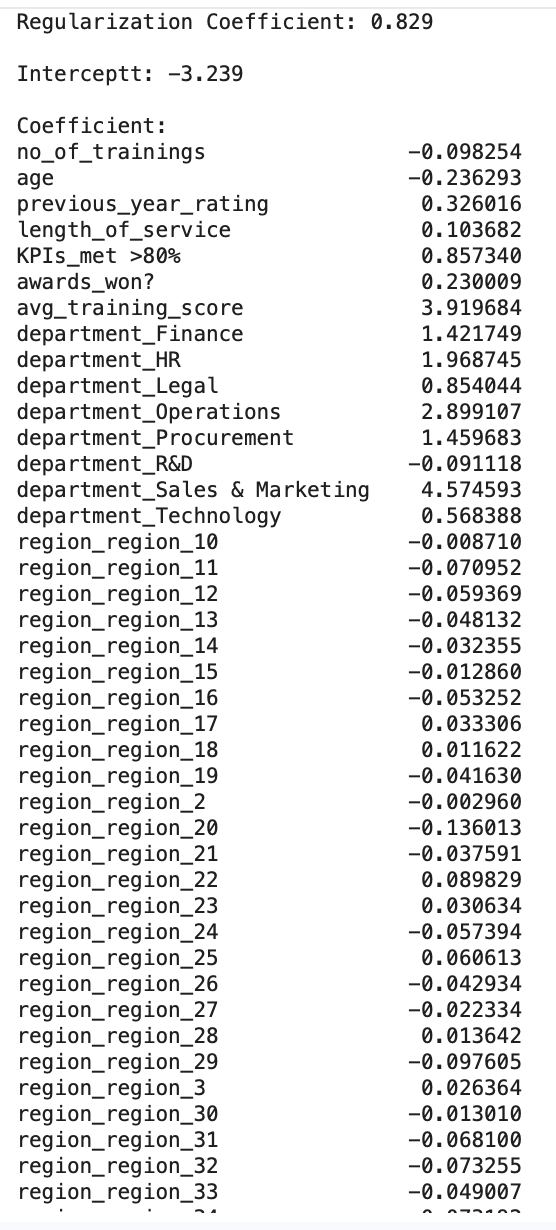

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

# Create pipeline
logit_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegressionCV(
        penalty="l2",
        Cs=50,
        cv=5,
        max_iter=1000,
        random_state=1
    ))
])

# Fit the model
logit_cv.fit(X_train, y_train)

# Extract model
model = logit_cv.named_steps["logreg"]

# Print chosen regularization coefficient
print("Regularization Coefficient:", round(model.C_[0], 3))

# Print intercept
print(f"\nIntercept: {model.intercept_[0]:.3f}")

# Print coefficients
print("\nCoefficient:")
for name, coef in zip(X_train.columns, model.coef_[0]):
    print(f"{name:<30} {coef:>10.6f}")

Regularization Coefficient: 0.829

Intercept: -3.239

Coefficient:
no_of_trainings                 -0.098254
age                             -0.236293
previous_year_rating             0.326016
length_of_service                0.103682
KPIs_met >80%                    0.857340
awards_won?                      0.230009
avg_training_score               3.919684
gender_m                         0.027577
department_Finance               1.421749
department_HR                    1.968745
department_Legal                 0.854044
department_Operations            2.899107
department_Procurement           1.459683
department_R&D                  -0.091118
department_Sales & Marketing     4.574593
department_Technology            0.568388
region_region_10                -0.008710
region_region_11                -0.070952
region_region_12                -0.059369
region_region_13                -0.048132
region_region_14                -0.032355
region_region_15                -0.012860
region_re

### Q11 What does **penalty: "l2"** achieve in the code above?

1. It will force the model to overfit
2. It will prevent model overfitting using Lasso
3. It will prevent model overfitting using Ridge
4. None of these

### Q12 Why do we need to perform feature scaling in this notebook? Choose the best answer.

1. We need to do feature scaling anytime we run a predictive model
2. We need to do feature scaling when we use a regularized model
3. We need to do feature scaling to ensure that our data does not suffer from class imbalance
4. It sounds cool

### Print out the confusion matrix for both training and test data

**Your output should look like this:**

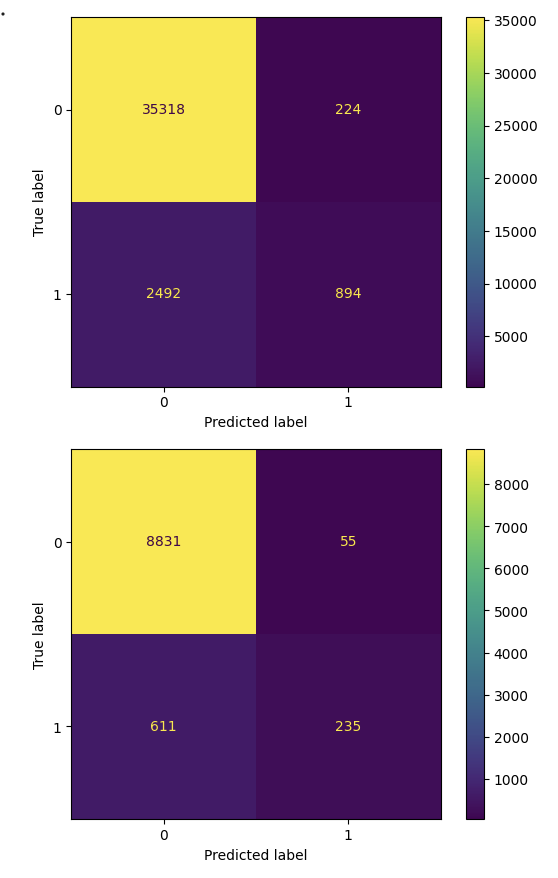

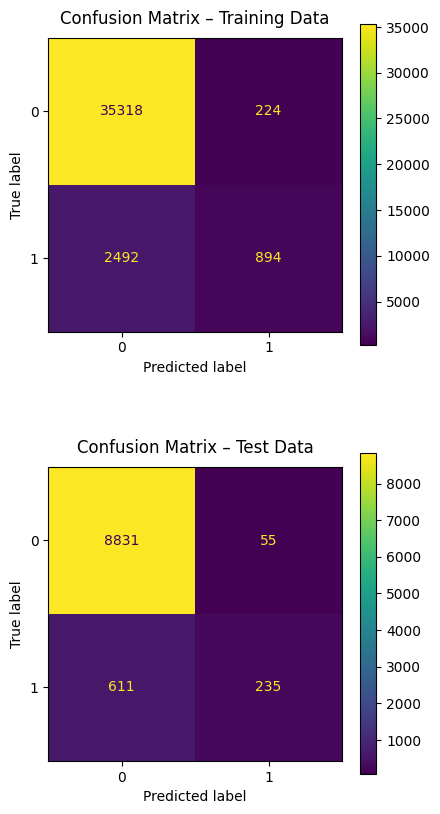

Confusion Matrix for Training Data:
  True Negative: 35318  | False Positive: 224 
  False Negative: 2492  | True Positive: 894 

Confusion Matrix for Test Data:
  True Negative: 8831   | False Positive: 55  
  False Negative: 611   | True Positive: 235 


In [ ]:
# Generate confusion matrix for train and test data
import numpy as np
cm_train = np.array([[35318,  224],
                     [ 2492,  894]])


cm_test  = np.array([[ 8831,   55],
                     [  611,  235]])

# Initialize matrix
fig, axes = plt.subplots(2, 1, figsize=(5, 9))

for ax, cm, title in zip(axes,
                          [cm_train, cm_test],
                          ["Confusion Matrix – Training Data",
                           "Confusion Matrix – Test Data"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=[0, 1])
    disp.plot(ax=ax,
              cmap="viridis",
              colorbar=True,
              values_format="d")
    ax.set_title(title, pad=10)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout(pad=3)
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# Print labels for matrix
print("Confusion Matrix for Training Data:")
print(f"  True Negative: {cm_train[0,0]:<6} | False Positive: {cm_train[0,1]:<4}")
print(f"  False Negative: {cm_train[1,0]:<5} | True Positive: {cm_train[1,1]:<4}\n")

print("Confusion Matrix for Test Data:")
print(f"  True Negative: {cm_test[0,0]:<6} | False Positive: {cm_test[0,1]:<4}")
print(f"  False Negative: {cm_test[1,0]:<5} | True Positive: {cm_test[1,1]:<4}")

### Q13 The count of false positives reported in the test dataset: 55



1.   55
2.   235
3.   611
4.   8831



### Q14 Choose the correct option.  A and B

* Statement A: The model correctly recommends promotion for 235 deserving employees in the test data.
* Statement B: The model incorrectly recommends non-promotion for 611 employees who deserve promotion in the test data

1. Only A is correct
2. Only B is correct
3. Both A and B are correct
4. Neither is correct




### Q15 What is the value generated by the model based on the test results?

**Hint: use the formula provided in the business problem description section, using the numbers from the confusion matrix on the test data**

In [ ]:
# Use formula to calculate the value generated by the test result model
value = total_predictions * 200 + FP * (-600) + FN * (-3000)
value = 9732 * 200 + 55 * (-600) + 611 * (-3000)
value = 1946400 - 33000 - 1833000
print(f"Value = ${value:,} USD")

Value = $80,400 USD


### Compute training and test precision/recall/F1 scores and print training and test classification reports


**Your output should look like this:**

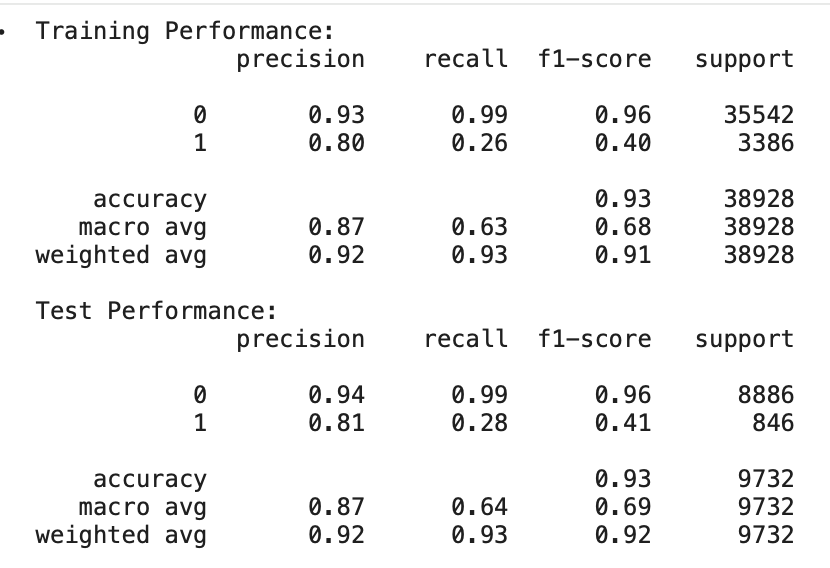

In [ ]:
# Initialize variables for train and test data
y_train_pred = logit_cv.predict(X_train)
y_test_pred  = logit_cv.predict(X_test)

# Generate labels and print classification report
print("Training Performance:")
print(classification_report(y_train, y_train_pred, digits=2))

print("Test Performance:")
print(classification_report(y_test, y_test_pred, digits=2))

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Set and print values generated by the model
cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

total_predictions = TN + FP + FN + TP
value = total_predictions * 200 + FP * (-600) + FN * (-3000)

print(f"\nQ15 – Value Generated by the Model:")
print(f"  Total predictions : {total_predictions}")
print(f"  False Positives   : {FP}")
print(f"  False Negatives   : {FN}")
print(f"  Value = {total_predictions}×200 + {FP}×(−600) + {FN}×(−3000)")
print(f"  Value = {total_predictions*200:,} − {FP*600:,} − {FN*3000:,}")
print(f"  Value Generated   = ${value:,} USD")

Training Performance:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     35542
           1       0.80      0.26      0.40      3386

    accuracy                           0.93     38928
   macro avg       0.87      0.63      0.68     38928
weighted avg       0.92      0.93      0.91     38928

Test Performance:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      8886
           1       0.81      0.28      0.41       846

    accuracy                           0.93      9732
   macro avg       0.87      0.64      0.69      9732
weighted avg       0.92      0.93      0.92      9732


Q15 – Value Generated by the Model:
  Total predictions : 9732
  False Positives   : 55
  False Negatives   : 611
  Value = 9732×200 + 55×(−600) + 611×(−3000)
  Value = 1,946,400 − 33,000 − 1,833,000
  Value Generated   = $80,400 USD


### Q16 Choose the correct option regarding test performance.

* Statement A: The proportion of employees who deserve promotion are indeed recommended by the model for promotion is around 80%

* Statement B: The proportion of employees who are recommended by the model for promotion indeed deserve promotion is around 80%


1. Only A is correct
2. Only B is correct
3. Both A and B are correct
4. Neither is correct

### Q17 What can you conclude about overfitting based on the image shown above? <br>
Consider the classification report for model performance.

1. The model seems to suffer from overfitting as the testing performance seems higher than training performance
2. The model seems to suffer from underfitting as the testing performance seems higher than training performance
3. The model seems to suffer from overfitting as the training performance seems higher than testing performance
4. None of these


### Measure the overall model performance on the test set as follows:
- Plot the ROC curve and compute AUC score of ROC
- Plot precision-Recall Curve (PRC) and compute AUC score of PRC


**Your output should look like this:**

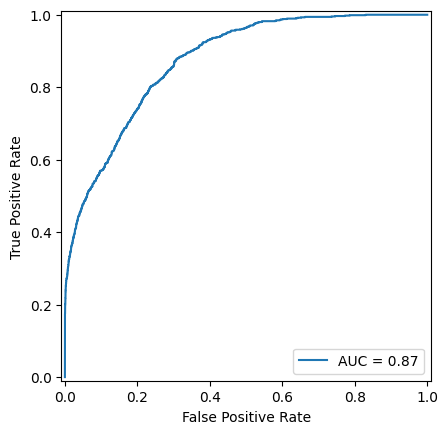


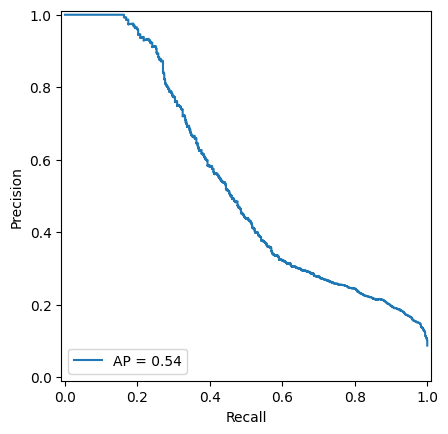

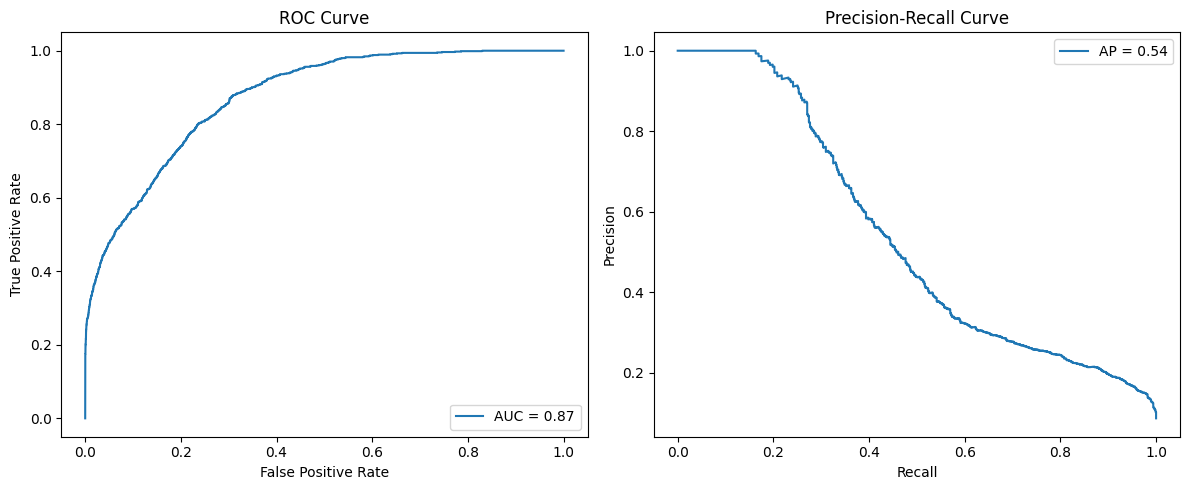

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Predict outcome probability using X_test
y_test_prob = logit_cv.predict_proba(X_test)[:, 1]

# Generate FPR and TPR
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_roc = roc_auc_score(y_test, y_test_prob)

# Set labels for plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

# Generate Precision and Recall
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)

# Set labels for second plot
axes[1].plot(recall, precision, label=f"AP = {ap:.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="upper right")

# Show plot
plt.tight_layout()
plt.show()

### Q18 What conclusions can you draw about the model overall performance based ROC and PRC curves? <br>

A. Although the model has an excellent ROC AUC score, the PRC AUC indicates the model's performance is not satisfactory.

B. The model is overfitting because ROC AUC is much higher than Average Precision, which always indicates poor generalization.

C. The dataset is not actually imbalanced, since ROC AUC would be much lower if class imbalance were present.

D. In extremely imbalanced datasets, ROC AUC can be misleading because it evaluates performance using the false positive rate (FPR), which is normalized by the large number of negative examples. As a result, even many false positives can correspond to a small FPR, yielding a high ROC AUC while precision remains relatively low.